In [1]:
### Train localizer to find period of greatest stability--use this to average classification for time-locked responses


# GAO decoding analysis
# 
import pandas as pd
import glob
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, roc_auc_score
import scipy.stats as stats
from scipy.interpolate import interp1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from joblib import Parallel, delayed
from sklearn.base import clone
from mne.time_frequency import tfr_array_morlet
import pingouin as pg

from utils.gao_functions import red_color, blue_color, red_palette, blue_palette, purple_color, purple_palette, lightblue_color, lightred_color, lightblue_palette, lightred_palette, calculate_vtc, calculate_BF, plot_BF_subplot, get_image_cat, make_timecourse_plot

# sm = SMOTE(random_state=42)
# X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# import numpy as np
# from scipy.io import loadmat
# import pandas as pd
import os
os.environ["R_HOME"] = r"/Library/Frameworks/R.framework/Resources"

from rpy2.robjects import r
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
import matplotlib.pyplot as plt
import seaborn as sns

bf_package=importr('BayesFactor')


# rus = RandomUnderSampler(random_state=42)

import matplotlib.pyplot as plt
from matplotlib import colors

import mne
# from mne.datasets import sample
from mne.decoding import (
    CSP,
    GeneralizingEstimator,
    LinearModel,
    Scaler,
    # LogisticRegression,
    SlidingEstimator,
    Vectorizer,
    cross_val_multiscore,
    # get_coef,
)

clf = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(store_covariance=True))
experiment_name = 'GAO'


from included_subs import subs

# CHECK UD/LR MAPPING _ DO NAMES MATCH NUMBERS?
dot_direction_map = {'UD':41, 'LR':42}
cat_map = {'vehicle':31, 'food': 32}

train_image_triggers = [11, 12] #vehicle, food
train_gabor_triggers = [21, 22] #Vertical, horizontal

test_image_triggers = [31, 32]# vehicle, food
test_gabor_triggers = [41, 42]# Vertical, horizontal

# smooth_VTC = 'yes'
# if smooth_VTC == 'yes':
#     vtc_variable = 'vtc_smooth_detrended'
# elif smooth_VTC == 'no':
#     vtc_variable = 'vtc_detrended'
# else:
#     print('smooth_VTC must be either yes or no!')
font_sz = 18
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.labelsize'] = font_sz
plt.rcParams['ytick.labelsize'] = font_sz
plt.rcParams['axes.titlesize'] = font_sz
plt.rcParams['legend.fontsize'] = font_sz - 4

figdir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/figures/'

exclude_ppt_channels = 'yes'
exclude_channels = {
    '01':['TP9','Fp1','Fp2','P3'],
    '02':['CP6','T7','TP9','Fp1','Fp2'],
    '03':['F4','TP9','Fp1','Fp2'],
    '04':['TP9','Fp1','Fp2'],
    '05':['FC5','TP9','Fp1','Fp2'],
    '06':['TP9','Fp1','Fp2'],
    '07':['TP9','Fp1','Fp2'],
    '08':['T8', 'CP2', 'FT9', 'T7', 'TP9','Fp1','Fp2'],
    '09':['TP9','Fp1','Fp2'],
    '10':['T8', 'TP9','Fp1','Fp2'],
    '11':['C3', 'TP9','Fp1','Fp2'],
    '12':['TP9','Fp1','Fp2'],
    '13':['TP9','Fp1','Fp2'],
    '14':['T7','T8','FC2','P7','Cz','CP2', 'TP9','Fp1','Fp2'],
    '15':['TP9','Fp1','Fp2'],
    '16':['TP9','Fp1','Fp2'],
    '17':['TP9','Fp1','Fp2','T7','T8'],
    '18':['TP9','Fp1','Fp2','C4','FC1'],
    '19':['TP9','Fp1','Fp2','FT10','FT9','T7','FC6'],
    '20':['TP9','Fp1','Fp2'],
    '21':['TP9','Fp1','Fp2','F3','F4','T7'],
    '22':['TP9','Fp1','Fp2','FT10'],
    '23':['TP9','Fp1','Fp2'],
    '24':['TP9','Fp1','Fp2','FT10'],
    '25':['TP9','Fp1','Fp2','T7'],
    '26':['TP9','Fp1','Fp2'],
    '27':['TP9','Fp1','Fp2'],
    '28':['TP9','Fp1','Fp2','F3'],
    '29':['TP9','Fp1','Fp2','T8']
}






gabor_start_stop = [ 0.27, 0.4]
image_start_stop = [ 0.18, 0.8]

if 'epochs' not in vars():
    epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs = epochs_pre.copy().resample(200)
x_axis = epochs.times

image_mask = (epochs.times >= image_start_stop[0]) & (epochs.times <= image_start_stop[1])
gabor_mask = (epochs.times >= gabor_start_stop[0]) & (epochs.times <= gabor_start_stop[1])


# # For aligning decoding with response times 
# tmin, tmax = -0.8, 0.8
# new_times = np.linspace(tmin, tmax, 200)

Reading /Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif ...


/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_47373/1832534587.py:140: RuntimeWarning: This filename (/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')


    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated


In [4]:
from collections import defaultdict
def kfold_classifier(x_train_dict, y_train_dict, analysis_list, sub):

    for analysis in analysis_list:
        time_decod = SlidingEstimator(clf, n_jobs=None, scoring="roc_auc", verbose=True)
        im_scores = cross_val_multiscore(time_decod, x_train_dict[analysis], y_train_dict[analysis], cv=3, n_jobs=None)
        im_scores = np.mean(im_scores, axis=0)
        pd.DataFrame(im_scores).to_csv(f'/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/localizer_crossval_decoding/{sub}_{analysis}_decoding_timecourse.csv', header=None, index=None)

        # time_gen = GeneralizingEstimator(clf, n_jobs=None, scoring="roc_auc", verbose=True)
        # scores_im_tempgen = cross_val_multiscore(time_gen, x_train_dict[analysis], y_train_dict[analysis], cv=3, n_jobs=None)
        # # Mean scores across cross-validation splits
        # scores_im_tempgen = np.mean(scores_im_tempgen, axis=0)
        # pd.DataFrame(scores_im_tempgen).to_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{sub}_{analysis}_decoding_tempgen.csv', header=None, index=None)

    # return results_dict
    


def parallel_kfold_classification(x_train, y_train, analysis_list, sub, n_jobs=-1):
    """
    Run classification multiple times in parallel and average predictions.
    """
    results = Parallel(n_jobs=n_jobs)(
        delayed(kfold_classifier)(x_train, y_train, analysis_list, sub)
        for i in range(1)
    )


In [6]:
FWHM = 4
# subs=['20','21','22','23','24','25','26','27','28','29']

for sub in subs:
    behav_dir = '/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/raw_data/raw_behavioral/' + sub + '/'
    eeg_dir = '/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'


    behav_files = glob.glob(behav_dir + sub + '*.csv')
    print(behav_files)
    if len(behav_files)==1:
        behav_file = pd.read_csv(behav_files[0])
    else:
        print('Multiple (or zero) behavioral files found for subject ' + sub)

    behav_file = behav_file[behav_file['task'].notna()]
    behav_file = behav_file[~behav_file['task'].str.contains('practice')]
    dot_training_trials = behav_file[behav_file['task']=='train_dots']
    cat_training_trials = behav_file[behav_file['task']=='train_image_cat']


    # Load preprocessed EEG data--remove artifacts
    epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs=epochs_pre.copy().resample(200, npad='auto')
    # epochs_resampled = epochs.copy().resample(100, npad='auto')
    events = pd.read_csv(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_events.tsv', header=0, sep='\t')
    # Drop TP9
    if exclude_ppt_channels == 'yes':
        epochs.drop_channels(exclude_channels[sub])
    else:
        epochs.drop_channels(['TP9','Fp1','Fp2'])

    artifacts = np.load(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_rejection_flags.npy')
    print(artifacts)

    epochs.drop(artifacts)
    events = events[~artifacts]


    # behav_plusmem = behav_join_DF.copy()
    # behav_join_DF = behav_join_DF[~behav_join_DF['task_x'].str.contains('memory')]
    # behav_join_DF = behav_join_DF.reset_index(drop=True)
    # behav_join_DF = behav_join_DF[~artifacts]


    x_data = epochs.get_data(picks='eeg')

    x_data_eyegaze = epochs.get_data(picks=['eyegaze'])
    x_data_pupil = epochs.get_data(picks=['pupil'])
    x_data_eog = epochs.get_data(picks=['eog'])

    # Get labeled trials
    x_train_image = x_data[events.value.isin(train_image_triggers)]
    x_test_image = x_data[events.value.isin(test_image_triggers)]
    x_train_gabor = x_data[events.value.isin(train_gabor_triggers)]
    x_test_gabor = x_data[events.value.isin(test_gabor_triggers)]

    y_train_image = events[events.value.isin(train_image_triggers)].value
    y_test_image = events[events.value.isin(test_image_triggers)].value
    y_train_gabor = events[events.value.isin(train_gabor_triggers)].value
    y_test_gabor = events[events.value.isin(test_gabor_triggers)].value



    ### K-fold localizer for training data

    analysis_list = ['image','gabor']
    x_train_dict={'image': x_train_image,
                  'gabor': x_train_gabor}
    y_train_dict={'image': y_train_image,
                  'gabor': y_train_gabor}


    parallel_kfold_classification(x_train_dict, y_train_dict, analysis_list, sub)


['/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/raw_data/raw_behavioral/01/01_data_2025_Oct_29_1041_5.csv']
Reading /Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif ...


/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_47373/1314804600.py:23: RuntimeWarning: This filename (/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')


    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False  True ... False  True False]
Dropped 2183 epochs: 2, 6, 7, 8, 9, 11, 15, 19, 20, 21, 22, 25, 28, 29, 31, 33, 35, 36, 38, 39, 40, 41, 42, 44, 46, 47, 49, 50, 54, 55, 57, 59, 60, 64, 65, 69, 73, 75, 77, 80, 84, 85, 89, 93, 96, 99, 101, 106, 108, 111, 113, 114, 118, 122, 125, 129, 130, 133, 136, 141, 142, 144, 147, 149, 151, 153, 156, 157, 158, 161, 165, 168, 170, 172, 173, 176, 177, 179, 181, 183, 186, 188, 191, 192, 194, 197, 200, 204, 205, 207, 208, 210, 213, 216, 219, 222, 228, 230, 233, 234, 235, 236, 239, 240, 241, 245, 246, 248, 251, 252, 255, 256, 260, 261, 262, 264, 266, 269, 271, 272, 273, 276, 279, 283, 285, 287, 290, 291, 293, 294, 295, 297, 298, 300, 301, 302, 303, 304, 305, 307, 310, 312, 314, 316, 318, 319, 321, 322, 324, 325, 

100%|██████████| Fitting SlidingEstimator : 190/190 [00:00<00:00,  212.87it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:00<00:00,  225.53it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:00<00:00,  218.11it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  173.98it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  169.91it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:00<00:00,  213.41it/s]


['/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/raw_data/raw_behavioral/02/02_data_2025_Oct_31_0936_5.csv']
Reading /Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-02/eeg/sub-02_task-GAO_desc-preprocessed_eeg.fif ...


...

100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  137.88it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  165.08it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  155.93it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  160.41it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  145.96it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  156.92it/s]


['/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/raw_data/raw_behavioral/29/29_data_2026_Feb_13_1124_5.csv']
Reading /Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-29/eeg/sub-29_task-GAO_desc-preprocessed_eeg.fif ...


/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_47373/1314804600.py:23: RuntimeWarning: This filename (/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-29/eeg/sub-29_task-GAO_desc-preprocessed_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')


    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False False ... False False False]
Dropped 1595 epochs: 5, 6, 14, 19, 20, 29, 32, 38, 40, 41, 42, 43, 49, 50, 51, 52, 53, 55, 56, 58, 60, 63, 66, 68, 69, 75, 82, 88, 90, 93, 104, 112, 113, 124, 128, 136, 146, 154, 164, 165, 176, 191, 203, 206, 208, 218, 219, 220, 227, 232, 234, 242, 243, 250, 254, 264, 273, 278, 285, 291, 298, 310, 311, 320, 321, 331, 336, 337, 342, 347, 351, 357, 358, 364, 365, 366, 373, 377, 391, 394, 395, 401, 414, 422, 436, 437, 446, 453, 464, 466, 469, 476, 484, 485, 486, 490, 494, 499, 507, 509, 511, 512, 518, 519, 527, 534, 542, 551, 552, 555, 556, 563, 572, 575, 579, 580, 581, 588, 589, 594, 600, 604, 615, 626, 627, 632, 633, 645, 650, 657, 659, 670, 676, 687, 691, 700, 701, 705, 709, 712, 717, 725, 728, 729, 734, 737, 7

100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  179.21it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:00<00:00,  199.58it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:00<00:00,  196.83it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:01<00:00,  173.30it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:00<00:00,  191.72it/s]
100%|██████████| Fitting SlidingEstimator : 190/190 [00:00<00:00,  204.84it/s]


In [ ]:


# rel_acc_tempgen_image = []
# rel_acc_tempgen_gabor = []

# for sub in subs:
#     rel_acc_im = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{sub}_image_decoding_tempgen.csv', header=None)
#     rel_acc_tempgen_image.append(rel_acc_im)
#     rel_acc_gab = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{sub}_gabor_decoding_tempgen.csv', header=None)
#     rel_acc_tempgen_gabor.append(rel_acc_gab)


# print('calculating image BFs')
# rel_acc_stack_image = np.stack(rel_acc_tempgen_image, axis=0)
# bf_tempgen_image = calculate_BF_tempgen(rel_acc_stack_image, 0.5)
# bf_tempgen_image.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/tempgen_BF_image_AUC.csv', header=False, index=False)

# print('calculating gabor BFs')
# rel_acc_stack_gabor = np.stack(rel_acc_tempgen_gabor, axis=0)
# bf_tempgen_gabor = calculate_BF_tempgen(rel_acc_stack_gabor, 0.5)
# bf_tempgen_gabor.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/tempgen_BF_gabor_AUC.csv', header=False, index=False)



calculating image BFs
(1, 190)
(2, 190)
(3, 190)
(4, 190)
(5, 190)
(6, 190)
(7, 190)
(8, 190)
(9, 190)
(10, 190)
(11, 190)
(12, 190)
(13, 190)
(14, 190)
(15, 190)
(16, 190)
(17, 190)
(18, 190)
(19, 190)
(20, 190)
(21, 190)
(22, 190)
(23, 190)
(24, 190)
(25, 190)
(26, 190)
(27, 190)
(28, 190)
(29, 190)
(30, 190)
(31, 190)
(32, 190)
(33, 190)
(34, 190)
(35, 190)
(36, 190)
(37, 190)
(38, 190)
(39, 190)
(40, 190)
(41, 190)
(42, 190)
(43, 190)
(44, 190)
(45, 190)
(46, 190)
(47, 190)
(48, 190)
(49, 190)
(50, 190)
(51, 190)
(52, 190)
(53, 190)
(54, 190)
(55, 190)
(56, 190)
(57, 190)
(58, 190)
(59, 190)
(60, 190)
(61, 190)
(62, 190)
(63, 190)
(64, 190)
(65, 190)
(66, 190)
(67, 190)
(68, 190)
(69, 190)
(70, 190)
(71, 190)
(72, 190)
(73, 190)
(74, 190)
(75, 190)
(76, 190)
(77, 190)
(78, 190)
(79, 190)
(80, 190)
(81, 190)
(82, 190)
(83, 190)
(84, 190)
(85, 190)
(86, 190)
(87, 190)
(88, 190)
(89, 190)
(90, 190)
(91, 190)
(92, 190)
(93, 190)
(94, 190)
(95, 190)
(96, 190)
(97, 190)
(98, 190)
(99, 19

In [7]:
from statannotations.Annotator import Annotator


def make_localizer_timecourse_plot(plot_dict):


    DF = pd.DataFrame({plot_dict['bar1_label']: plot_dict['bar1'], plot_dict['bar2_label']: plot_dict['bar2'], plot_dict['bar3_label']: plot_dict['bar3']})
    DF_long = pd.melt(DF)
    print(pg.ttest(plot_dict['bar1'], plot_dict['bar2'], paired=True))
    print(pg.ttest(plot_dict['bar1'], plot_dict['bar3'], paired=True))

    print(plot_dict['bar1_label'])
    print(np.mean(plot_dict['bar1']))
    print(np.std(plot_dict['bar1']))
    print(plot_dict['bar2_label'])
    print(np.mean(plot_dict['bar2']))
    print(np.std(plot_dict['bar2']))
    print(plot_dict['bar3_label'])
    print(np.mean(plot_dict['bar3']))
    print(np.std(plot_dict['bar3']))

    fig = plt.figure(figsize=(15, 6))
    gs = fig.add_gridspec(
        nrows=3,
        ncols=2,
        width_ratios=[3, 1.5],
        height_ratios=[3, 1, 1],
        wspace=0.1,
        hspace=0.4
    )

    # Left column
    ax_dec = fig.add_subplot(gs[0, 0])
    ax_bf = fig.add_subplot(gs[1, 0])
    ax_bf2 = fig.add_subplot(gs[2, 0])

    # Right side of decoding plot
    ax_in_irrel = fig.add_subplot(gs[0, 1], sharey=ax_dec)
    # ax_out_irrel = fig.add_subplot(gs[0, 2], sharey=ax_dec)


    # fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), gridspec_kw={'wspace': 0.4, 'hspace': 0.4, 'height_ratios': [3, 1]})
    ax_dec.plot(plot_dict['x_axis'], plot_dict['tc1'], plot_dict['tc1_color'], linestyle='-',label=plot_dict['tc1_label'])
    ax_dec.fill_between(plot_dict['x_axis'], plot_dict['tc1'] - plot_dict['tc1_SE'], plot_dict['tc1'] + plot_dict['tc1_SE'], color=plot_dict['tc1_color'], alpha=0.3)
    ax_dec.plot(plot_dict['x_axis'], plot_dict['tc2'], plot_dict['tc2_color'], linestyle=plot_dict['tc2_linestyle'],label=plot_dict['tc2_label'])
    ax_dec.fill_between(plot_dict['x_axis'], plot_dict['tc2'] - plot_dict['tc2_SE'], plot_dict['tc2'] + plot_dict['tc2_SE'], color=plot_dict['tc2_color'], alpha=0.3)
    ax_dec.plot(plot_dict['x_axis'], plot_dict['tc3'], plot_dict['tc3_color'], linestyle=plot_dict['tc3_linestyle'],label=plot_dict['tc3_label'])
    ax_dec.fill_between(plot_dict['x_axis'], plot_dict['tc3'] - plot_dict['tc3_SE'], plot_dict['tc3'] + plot_dict['tc3_SE'], color=plot_dict['tc3_color'], alpha=0.3)
    ax_dec.set_ylim(0.45, 0.7)
    ax_dec.set_yticks([0.5, 0.6, 0.7])


    ax_dec.spines['right'].set_visible(False)
    ax_dec.spines['top'].set_visible(False)
    ax_dec.axhline(0.5, color="k", linestyle="--")
    ax_dec.set_ylabel("Area under\nthe curve", fontsize=font_sz)  # Area Under the Curve
    ax_dec.legend(frameon=False, framealpha=0)
    ax_dec.axvline(0.0, color="k", linestyle="-")
    # ax_dec.set_title("Irrelevant image category decoding", fontsize=font_sz)
    ax_dec.set_xticks([])

    pairs = [(plot_dict['bar1_label'], plot_dict['bar2_label']), (plot_dict['bar1_label'], plot_dict['bar3_label'])]
    bf10 = float(pg.ttest(plot_dict['bar1'], plot_dict['bar2'], paired=True)['BF10'].values[0])
    print(bf10)
    if bf10 > 10000 or bf10 < 0.001:
        formatted_bf = r"$\mathrm{BF}_{10}$" + f" = {bf10:.2e}"
    else:
        formatted_bf = r"$\mathrm{BF}_{10}$" + f" = {bf10:.2f}"

    bf10_2 = float(pg.ttest(plot_dict['bar1'], plot_dict['bar3'], paired=True)['BF10'].values[0])
    print(bf10_2)
    if bf10_2 > 10000 or bf10_2 < 0.001:
        formatted_bf_2 = r"$\mathrm{BF}_{10}$" + f" = {bf10_2:.2e}"
    else:
        formatted_bf_2 = r"$\mathrm{BF}_{10}$" + f" = {bf10_2:.2f}"

    custom_annotations = [formatted_bf, formatted_bf_2]
    print(custom_annotations)

    annotator = Annotator(ax_in_irrel, pairs, data=DF_long, x="variable", y="value")
    annotator.configure(loc='outside', fontsize=font_sz)
    annotator.set_custom_annotations(custom_annotations)
    annotator.annotate()

    sns.boxplot(x="variable", y="value", data=DF_long, hue="variable", palette = [plot_dict['tc1_color'], plot_dict['tc2_color'], plot_dict['tc3_color']], linewidth=2, fliersize=0,  ax=ax_in_irrel)
    sns.stripplot(x="variable", y="value", data=DF_long, color="black", alpha=0.5, ax=ax_in_irrel)
    # ax_in_irrel.scatter(0,np.mean(in_irrel_mean), color='white')
    ax_in_irrel.axhline(0.5, color="k", linestyle="--")
    ax_in_irrel.set_xlabel("")
    ax_in_irrel.set_ylabel("")
    sns.despine(right=True)

    # ax_out_irrel.tick_params(axis='y', left=False, labelleft=False)

    plot_BF_subplot(plot_dict['x_axis'], plot_dict['BF'], plot_dict['BF_palette'], ax=ax_bf, title=plot_dict['BF_title'], topLim=plot_dict['BF_top'], bottomLim=2, xlabel=False)
    plot_BF_subplot(plot_dict['x_axis'], plot_dict['BF2'], plot_dict['BF2_palette'], ax=ax_bf2, title=plot_dict['BF2_title'], topLim=plot_dict['BF2_top'], bottomLim=2, xlabel=True)

    # plt.show()
    plt.savefig(plot_dict['save_name'], bbox_inches='tight')
    plt.show()




/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val          CI95%   cohen-d   BF10  \
T-test -0.064892   24   two-sided  0.948798  [-0.01, 0.01]  0.010074  0.211   

           power  
T-test  0.050268  
               T  dof alternative         p-val         CI95%   cohen-d  \
T-test  8.052526   24   two-sided  2.810255e-08  [0.02, 0.03]  1.201789   

             BF10     power  
T-test  4.909e+05  0.999926  
localizer
0.5535067066339601
0.020869855508403312
relevant
0.5537293413817111
0.022411402916653507
irrelevant
0.530139181854711
0.01703929620292293
0.211
490900.0
['$\\mathrm{BF}_{10}$ = 0.21', '$\\mathrm{BF}_{10}$ = 4.91e+05']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

localizer vs. relevant: $\mathrm{BF}_{10}$ = 0.21
localizer vs. irrelevant: $\mathrm{BF}_{10}$ = 4.91e+05


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


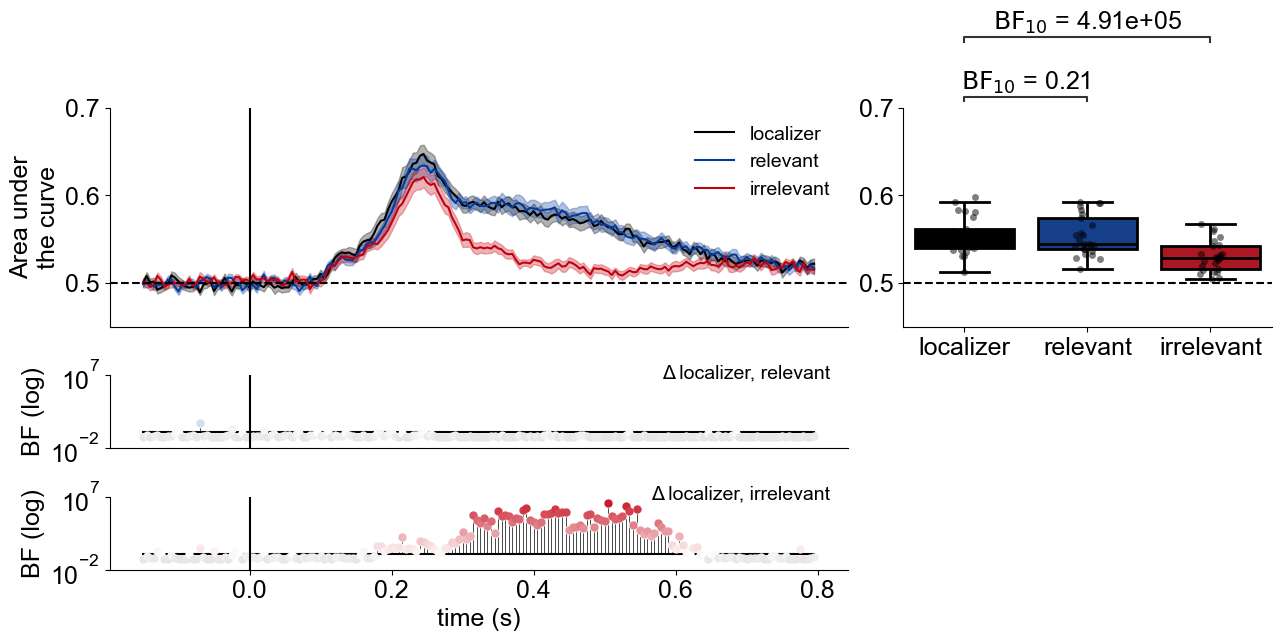

In [8]:

if 'epochs' not in vars():
    epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs = epochs_pre.copy().resample(200)
x_axis = epochs.times

rel_acc_df = pd.DataFrame()
loc_acc_df = pd.DataFrame()
irrel_acc_df = pd.DataFrame()
kfold_df = pd.DataFrame()
# subs=['01','02','03','04','05','06','07','08','10','12','13','14','15','17','18','20','21','22','23','24','25','26','27','28','29']
rel_mean = []
irrel_mean = []
loc_mean = []
# subs=['01']
for s in subs:
    # k_fold = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{s}_image_decoding_timecourse.csv', header=None)
    # kfold_df = pd.concat([kfold_df, k_fold.T],axis=0)
    rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_relevant_AUC_check.csv', header=None)
    rel_acc_df= pd.concat([rel_acc_df, rel_acc.T], axis=0)
    rel_mean.append(np.mean(rel_acc[epochs.times>0.0]))
    irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_image_irrelevant_AUC_check.csv', header=None)
    irrel_acc_df= pd.concat([irrel_acc_df, irrel_acc.T], axis=0)
    irrel_mean.append(np.mean(irrel_acc[epochs.times>0.0]))
    loc_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/localizer_crossval_decoding/' + s + '_image_decoding_timecourse.csv', header=None)
    loc_acc_df = pd.concat([loc_acc_df, loc_acc.T], axis=0)
    loc_mean.append(np.mean(loc_acc[epochs.times>0.0]))


mean_rel_acc = np.mean(rel_acc_df, axis=0)
mean_irrel_acc = np.mean(irrel_acc_df, axis=0)
mean_kfold = np.mean(loc_acc_df, axis=0)

SE_rel = stats.sem(rel_acc_df, axis=0)
SE_irrel = stats.sem(irrel_acc_df, axis=0)
SE_kfold = stats.sem(loc_acc_df, axis=0)



bf_diff = calculate_BF(loc_acc_df, rel_acc_df)
bf_diff2 = calculate_BF(loc_acc_df, irrel_acc_df)







plot_dict_rel = {
    'tc1': mean_kfold, 
    'tc1_label': "localizer",
    'tc2': mean_rel_acc, 
    'tc2_label': "relevant",
    'tc2_linestyle':'-',

    'tc3': mean_irrel_acc,
    'tc3_label': "irrelevant",
    'tc1_SE': SE_kfold,
    'tc2_SE': SE_rel,
    'tc3_SE': SE_irrel,
    'tc1_color': 'black',
    'tc2_color': blue_color,
    'tc3_color': red_color,
    'tc3_linestyle':'-',
    'bar1': loc_mean,
    'bar1_label': 'localizer',
    'bar2': rel_mean,
    'bar2_label': 'relevant',
    'bar3_label': 'irrelevant',
    'bar3': irrel_mean,
    'BF': bf_diff,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 localizer, relevant",
    'BF_top':7,
    'BF2': bf_diff2,
    'BF2_palette': red_palette,
    'BF2_title':"\u0394 localizer, irrelevant",
    'BF2_top':7,
    'x_axis': epochs.times,
    'save_name':figdir + 'SuppFig1_image_onsetlocked.png'
}

make_localizer_timecourse_plot(plot_dict_rel)


/Users/annacorriveau/miniconda3/envs/gao_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


               T  dof alternative     p-val        CI95%   cohen-d    BF10  \
T-test  3.882905   24   two-sided  0.000708  [0.0, 0.02]  0.866714  47.045   

         power  
T-test  0.9859  
               T  dof alternative    p-val         CI95%   cohen-d      BF10  \
T-test  5.293739   24   two-sided  0.00002  [0.01, 0.02]  1.432088  1161.562   

        power  
T-test    1.0  
localizer
0.5225434157272134
0.01387161399886089
relevant
0.5122235732632352
0.008932143480948783
irrelevant
0.5055884492808672
0.008758093764155603
47.045
1161.562
['$\\mathrm{BF}_{10}$ = 47.05', '$\\mathrm{BF}_{10}$ = 1161.56']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

localizer vs. relevant: $\mathrm{BF}_{10}$ = 47.05
localizer vs. irrelevant: $\mathrm{BF}_{10}$ = 1161.56


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


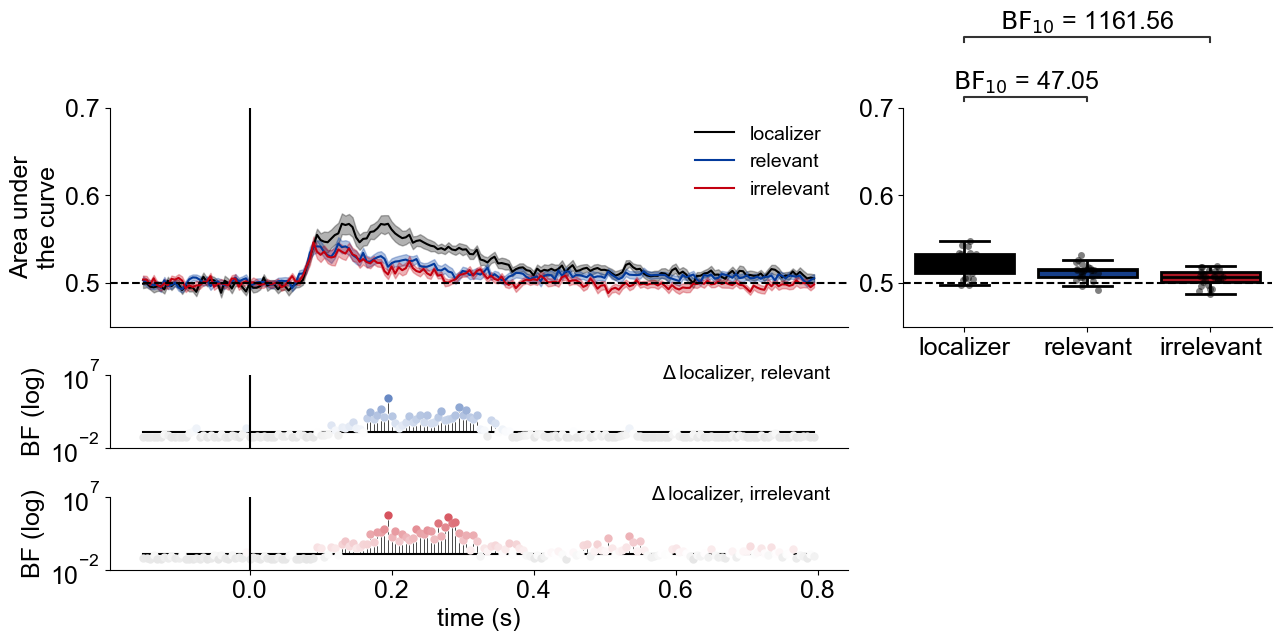

In [9]:

if 'epochs' not in vars():
    epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs = epochs_pre.copy().resample(200)
x_axis = epochs.times

rel_acc_df = pd.DataFrame()
loc_acc_df = pd.DataFrame()
irrel_acc_df = pd.DataFrame()
kfold_df = pd.DataFrame()
# subs=['01','02','03','04','05','06','07','08','10','12','13','14','15','17','18','20','21','22','23','24','25','26','27','28','29']
rel_mean = []
irrel_mean = []
loc_mean = []
# subs=['01']
for s in subs:
    # k_fold = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{s}_image_decoding_timecourse.csv', header=None)
    # kfold_df = pd.concat([kfold_df, k_fold.T],axis=0)
    rel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_relevant_AUC_check.csv', header=None)
    rel_acc_df= pd.concat([rel_acc_df, rel_acc.T], axis=0)
    rel_mean.append(np.mean(rel_acc[epochs.times>0.0]))
    irrel_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/timecourse_decoding/' + s + '_gabor_irrelevant_AUC_check.csv', header=None)
    irrel_acc_df= pd.concat([irrel_acc_df, irrel_acc.T], axis=0)
    irrel_mean.append(np.mean(irrel_acc[epochs.times>0.0]))
    loc_acc = pd.read_csv('/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/localizer_crossval_decoding/' + s + '_gabor_decoding_timecourse.csv', header=None)
    loc_acc_df = pd.concat([loc_acc_df, loc_acc.T], axis=0)
    loc_mean.append(np.mean(loc_acc[epochs.times>0.0]))


mean_rel_acc = np.mean(rel_acc_df, axis=0)
mean_irrel_acc = np.mean(irrel_acc_df, axis=0)
mean_kfold = np.mean(loc_acc_df, axis=0)

SE_rel = stats.sem(rel_acc_df, axis=0)
SE_irrel = stats.sem(irrel_acc_df, axis=0)
SE_kfold = stats.sem(loc_acc_df, axis=0)



bf_diff = calculate_BF(loc_acc_df, rel_acc_df)
bf_diff2 = calculate_BF(loc_acc_df, irrel_acc_df)







plot_dict_rel = {
    'tc1': mean_kfold, 
    'tc1_label': "localizer",
    'tc2': mean_rel_acc, 
    'tc2_label': "relevant",
    'tc2_linestyle':'-',

    'tc3': mean_irrel_acc,
    'tc3_label': "irrelevant",
    'tc1_SE': SE_kfold,
    'tc2_SE': SE_rel,
    'tc3_SE': SE_irrel,
    'tc1_color': 'black',
    'tc2_color': blue_color,
    'tc3_color': red_color,
    'tc3_linestyle':'-',
    'bar1': loc_mean,
    'bar1_label': 'localizer',
    'bar2': rel_mean,
    'bar2_label': 'relevant',
    'bar3_label': 'irrelevant',
    'bar3': irrel_mean,
    'BF': bf_diff,
    'BF_palette': blue_palette,
    'BF_title':"\u0394 localizer, relevant",
    'BF_top':7,
    'BF2': bf_diff2,
    'BF2_palette': red_palette,
    'BF2_title':"\u0394 localizer, irrelevant",
    'BF2_top':7,
    'x_axis': epochs.times,
    'save_name':figdir + 'SuppFig1_gabor_onsetlocked.png'
}

make_localizer_timecourse_plot(plot_dict_rel)


(25, 190, 190)


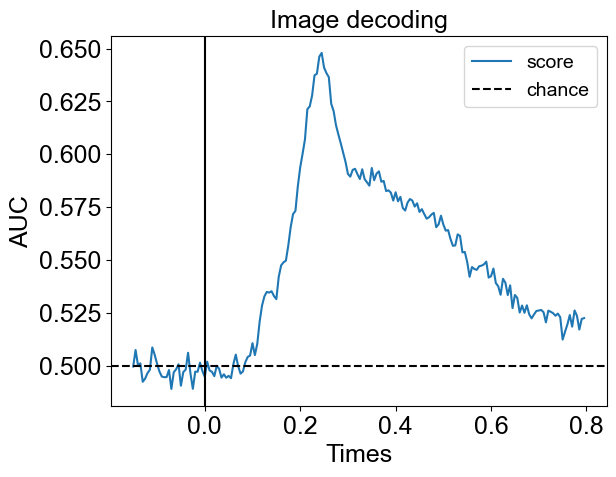

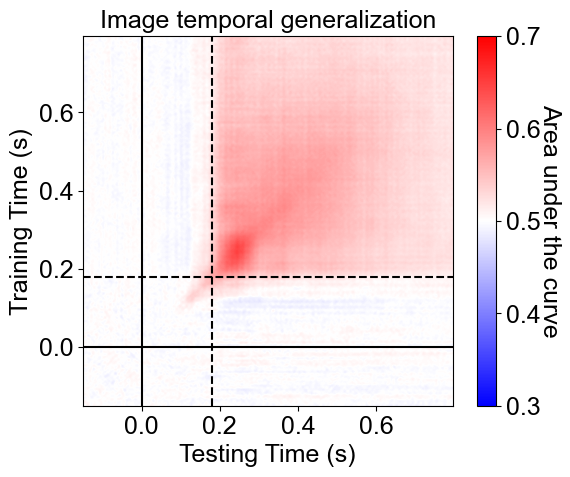

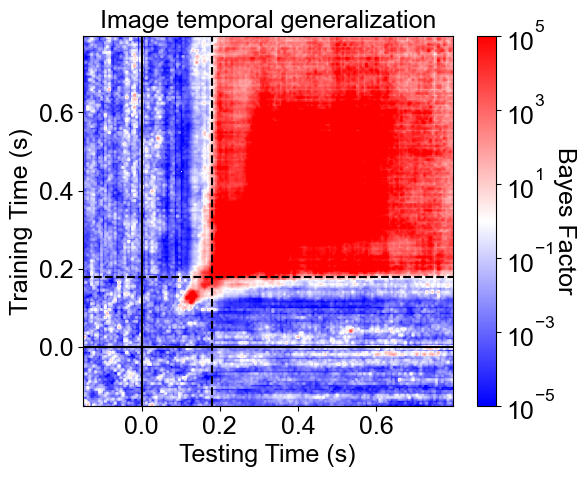

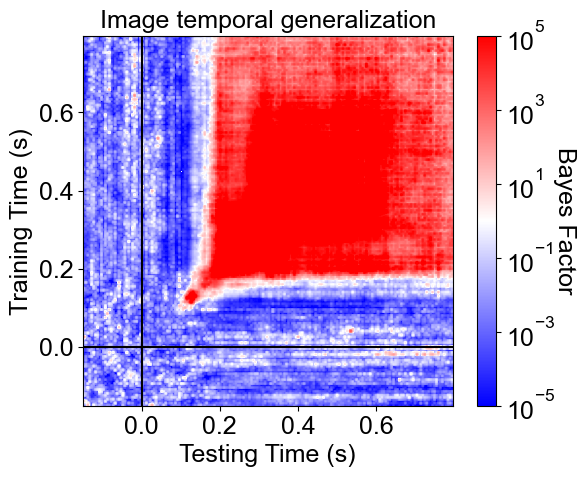

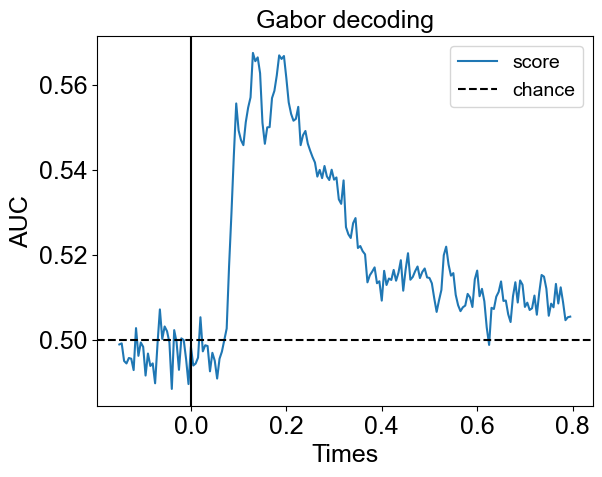

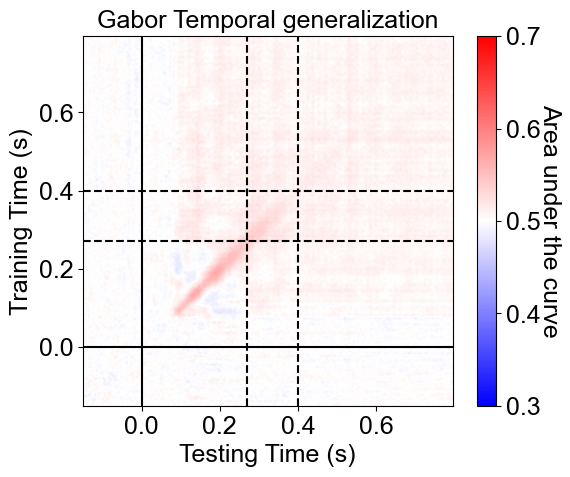

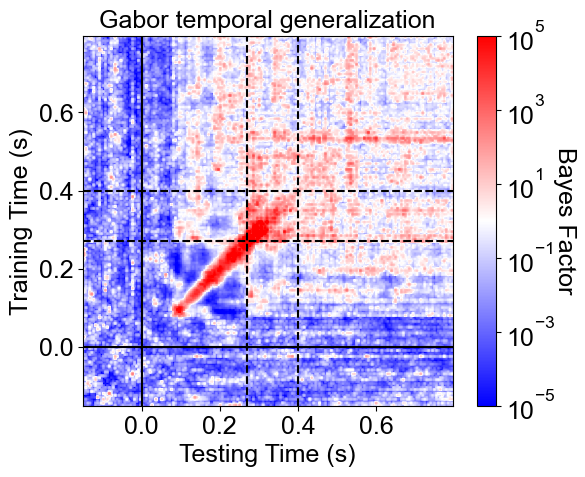

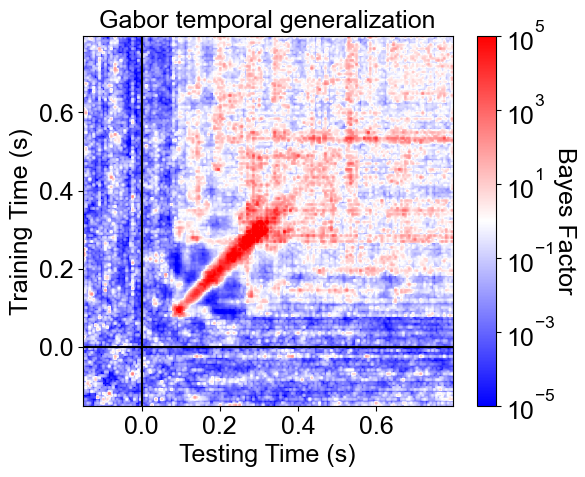

TypeError: 'tuple' object is not callable

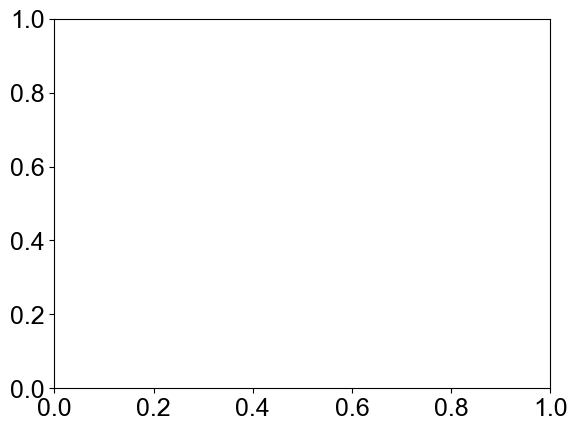

In [ ]:



# if 'epochs' not in vars():
#     epochs_pre = mne.read_epochs('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + '01' + '/eeg/' + 'sub-' + '01' + '_task-GAO_desc-preprocessed_eeg.fif')
#     epochs = epochs_pre.copy().resample(200)
    
image_acc_tempgen = []
gabor_acc_tempgen = []
# subs=['01','02','03','04','05','06','07','08','09','10','11','12']

for s in subs:
    rel_acc = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{s}_image_decoding_tempgen.csv', header=None)
    image_acc_tempgen.append(rel_acc)
    irrel_acc = pd.read_csv(f'/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/{s}_gabor_decoding_tempgen.csv', header=None)
    gabor_acc_tempgen.append(irrel_acc)

image_acc_stack = np.stack(image_acc_tempgen, axis=0)
gabor_acc_stack = np.stack(gabor_acc_tempgen, axis=0)
print(image_acc_stack.shape)
mean_image_acc = np.mean(image_acc_stack, axis=0)
mean_gabor_acc = np.mean(gabor_acc_stack, axis=0)


# Plot the diagonal (it's exactly the same as the time-by-time decoding above)
fig, ax = plt.subplots()
ax.plot(epochs.times, np.diag(mean_image_acc), label="score")
ax.axhline(0.5, color="k", linestyle="--", label="chance")
ax.set_xlabel("Times")
ax.set_ylabel("AUC")
ax.legend()
ax.axvline(0.0, color="k", linestyle="-")
ax.set_title("Image decoding")
plt.show()


fig, ax = plt.subplots(1, 1)
im = ax.imshow(
    mean_image_acc,
    interpolation="lanczos",
    origin="lower",
    cmap="bwr",
    extent=epochs.times[[0, -1, 0, -1]],
    vmin=.30,
    vmax=0.70,
)
ax.set_xlabel("Testing Time (s)")
ax.set_ylabel("Training Time (s)")
ax.set_xticks([0, 0.2, 0.4, 0.6])

ax.set_title("Image temporal generalization")
ax.axvline(0, color="k")
ax.axhline(0, color="k")
ax.axhline(image_start_stop[0], color="k", linestyle='--')
ax.axvline(image_start_stop[0], color="k", linestyle='--')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Area under the curve", rotation=270, labelpad=15)
plt.savefig(figdir + 'Supp1A_ImageTempGen.png', bbox_inches='tight')

plt.show()


# fig, ax = plt.subplots(1, 1)
# im = ax.imshow(
#     tmap_rel_acc_stack_image,
#     interpolation="lanczos",
#     origin="lower",
#     cmap="bwr",
#     extent=epochs.times[[0, -1, 0, -1]],
#     vmin=-15,
#     vmax=15,
# )
# ax.set_xlabel("Testing Time (s)")
# ax.set_ylabel("Training Time (s)")
# ax.set_xticks([0, 0.2, 0.4, 0.6])

# ax.set_title("Temporal generalization T-stats")
# ax.axvline(0, color="k")
# ax.axhline(0, color="k")
# ax.axhline(image_start_stop[0], color="k", linestyle='--')
# ax.axvline(image_start_stop[0], color="k", linestyle='--')
# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label("accuracy")
# plt.show()


# 2. Create a TwoSlopeNorm object
data_min = 0.00001
data_max = 100000.0
custom_norm = colors.LogNorm(vmin=data_min, vmax=data_max)

BF_DF_image = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/tempgen_BF_image_AUC', header=None)
fig, ax = plt.subplots()
img = ax.imshow(BF_DF_image, origin="lower", extent=epochs.times[[0, -1, 0, -1]], cmap = 'bwr', norm=custom_norm)#'PiYG'#norm=colors.LogNorm(vmin=np.min(np.min(BF_DF)), vmax=np.max(np.max(BF_DF))))
# ax.axvline()
ax.set_xlabel("Testing Time (s)")
ax.set_ylabel("Training Time (s)")
ax.set_xticks([0, 0.2, 0.4, 0.6])

ax.set_title("Image temporal generalization")
ax.axvline(0, color="k")
ax.axhline(0, color="k")

ax.axhline(image_start_stop[0], color="k", linestyle='--')
ax.axvline(image_start_stop[0], color="k", linestyle='--')
# ax.colorbar()
# Add the colorbar, linking it to the 'img' object
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Bayes Factor", rotation=270, labelpad=15)
plt.savefig(figdir + 'Supp1B_ImageBF_bwr.png', bbox_inches='tight')
# Display the plot
plt.show()


data_min = 0.00001
data_max = 100000.0
custom_norm = colors.LogNorm(vmin=data_min, vmax=data_max)

BF_DF_image = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/tempgen_BF_image_AUC', header=None)
fig, ax = plt.subplots()
img = ax.imshow(BF_DF_image, origin="lower", extent=epochs.times[[0, -1, 0, -1]], cmap = 'bwr', norm=custom_norm)#'PiYG'#norm=colors.LogNorm(vmin=np.min(np.min(BF_DF)), vmax=np.max(np.max(BF_DF))))
# ax.axvline()
ax.set_xlabel("Testing Time (s)")
ax.set_ylabel("Training Time (s)")
ax.set_xticks([0, 0.2, 0.4, 0.6])

ax.set_title("Image temporal generalization")
ax.axvline(0, color="k")
ax.axhline(0, color="k")

# ax.axhline(image_start_stop[0], color="k", linestyle='--')
# ax.axvline(image_start_stop[0], color="k", linestyle='--')
# # ax.colorbar()
# Add the colorbar, linking it to the 'img' object
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Bayes Factor", rotation=270, labelpad=15)
plt.savefig(figdir + 'Supp1B_ImageBF_noDashedLines.png', bbox_inches='tight')
# Display the plot
plt.show()



######## GABORS ########

# Plot the diagonal (it's exactly the same as the time-by-time decoding above)
fig, ax = plt.subplots()
ax.plot(epochs.times, np.diag(mean_gabor_acc), label="score")
ax.axhline(0.5, color="k", linestyle="--", label="chance")
ax.set_xlabel("Times")
ax.set_ylabel("AUC")
ax.legend()
ax.axvline(0.0, color="k", linestyle="-")
ax.set_title("Gabor decoding")


fig, ax = plt.subplots(1, 1)
im = ax.imshow(
    mean_gabor_acc,
    interpolation="lanczos",
    origin="lower",
    cmap="bwr",
    extent=epochs.times[[0, -1, 0, -1]],
    vmin=.30,
    vmax=0.70,
)
ax.set_xlabel("Testing Time (s)")
ax.set_ylabel("Training Time (s)")
ax.set_xticks([0, 0.2, 0.4, 0.6])

ax.set_title("Gabor Temporal generalization")
ax.axvline(0, color="k")
ax.axhline(0, color="k")

ax.axhline(gabor_start_stop[0], color="k", linestyle='--')
ax.axvline(gabor_start_stop[0], color="k", linestyle='--')
ax.axhline(gabor_start_stop[1], color="k", linestyle='--')
ax.axvline(gabor_start_stop[1], color="k", linestyle='--')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Area under the curve", rotation=270, labelpad=15)
plt.savefig(figdir + 'Supp1C_GaborTempGen.png', bbox_inches='tight')


# 2. Create a TwoSlopeNorm object
data_min = 0.00001
data_max = 100000.0
custom_norm = colors.LogNorm(vmin=data_min, vmax=data_max)

BF_DF_gabor = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/tempgen_BF_gabor_AUC', header=None)
fig, ax = plt.subplots()
img = ax.imshow(BF_DF_gabor, origin="lower", extent=epochs.times[[0, -1, 0, -1]], cmap = 'bwr', norm=custom_norm)#norm=colors.LogNorm(vmin=np.min(np.min(BF_DF)), vmax=np.max(np.max(BF_DF))))
# ax.axvline()
ax.set_xlabel("Testing Time (s)")
ax.set_xticks([0, 0.2, 0.4, 0.6])
ax.set_ylabel("Training Time (s)")
ax.set_title("Gabor temporal generalization")
ax.axvline(0, color="k")
ax.axhline(0, color="k")

ax.axhline(gabor_start_stop[0], color="k", linestyle='--')
ax.axvline(gabor_start_stop[0], color="k", linestyle='--')
ax.axhline(gabor_start_stop[1], color="k", linestyle='--')
ax.axvline(gabor_start_stop[1], color="k", linestyle='--')

# ax.colorbar()
# Add the colorbar, linking it to the 'img' object
cbar=plt.colorbar(img, ax=ax)
cbar.set_label("Bayes Factor", rotation=270, labelpad=15)
# cbar.ax.label()
plt.savefig(figdir + 'Supp1D_gaborBF_bwr.png', bbox_inches='tight')

# Display the plot
plt.show()


BF_DF_gabor = pd.read_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/output/localizer_crossval_decoding/tempgen_BF_gabor_AUC', header=None)
fig, ax = plt.subplots()
img = ax.imshow(BF_DF_gabor, origin="lower", extent=epochs.times[[0, -1, 0, -1]], cmap = 'bwr', norm=custom_norm)#norm=colors.LogNorm(vmin=np.min(np.min(BF_DF)), vmax=np.max(np.max(BF_DF))))
# ax.axvline()
ax.set_xlabel("Testing Time (s)")
ax.set_xticks([0, 0.2, 0.4, 0.6])
ax.set_ylabel("Training Time (s)")
ax.set_title("Gabor temporal generalization")
ax.axvline(0, color="k")
ax.axhline(0, color="k")

# ax.axhline(gabor_start_stop[0], color="k", linestyle='--')
# ax.axvline(gabor_start_stop[0], color="k", linestyle='--')
# ax.axhline(gabor_start_stop[1], color="k", linestyle='--')
# ax.axvline(gabor_start_stop[1], color="k", linestyle='--')

# ax.colorbar()
# Add the colorbar, linking it to the 'img' object
cbar=plt.colorbar(img, ax=ax)
cbar.set_label("Bayes Factor", rotation=270, labelpad=15)
# cbar.ax.label()
plt.savefig(figdir + 'Supp1D_gaborBF_noDashedLines.png', bbox_inches='tight')

# Display the plot
plt.show()



